# HW2 DAI Shi Yang Alris 1155179724

Apply batch gradient descent, mini-batch gradient descent, and stochastic gradient descent separately to solve the logistic regression problem in Example 2. Plot the cost function value versus iteration for all three methods. Use the solution $\theta $* obtained by batch gradient descent as the reference, and plot ||$\theta$ – $\theta$* || versus iteration for all three methods.

In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np
import random
#use seed 1
random.seed(1)
df = pd.read_csv("C:/Users/User/Desktop/5061/examples/example_data/logistic-regression-example-2.csv")
print(df)
df = df.apply(lambda x: x.fillna(random.choice(x.dropna())), axis=1)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4233     1   50        1.0              1         1.0     0.0   
4234     1   51        3.0              1        43.0     0.0   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

c:\Users\User\.conda\envs\5061_environment\Lib\random.py:374: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return seq[self._randbelow(len(seq))]


## Sigmoid Function and cost computation

In [2]:
def sigmoid(x):
    return np.exp(x) / (1 + np.exp(x))

def computeCost(theta,X,y):
    m = X.shape[0]
    predictions = sigmoid(np.dot(X, theta))
    cost = -(1/m) * (y.T.dot(np.log(predictions))+(1-y).T.dot(np.log(1-predictions)))
    return cost.flatten()[0]

## Feature scaling

In [3]:
df = df.to_numpy()
X = df[:,0:-1]
y = df[:,-1]
y = y.reshape((len(y),1))
n = X.shape[1]+1
print(X.shape)

from sklearn import preprocessing
scaler = preprocessing.RobustScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)
print(scaler)
X = X_scaled     #we want to use symbol X

print(X)

(4238, 15)
(4238, 15)
RobustScaler()
[[ 1.         -0.71428571  1.         ...  0.314       0.33333333
   0.        ]
 [ 0.         -0.21428571  0.         ...  0.666       1.33333333
  -0.0625    ]
 [ 1.         -0.07142857 -0.5        ... -0.012       0.
  -0.4375    ]
 ...
 [ 0.         -0.07142857  0.         ... -0.68        0.6
   0.5625    ]
 [ 0.         -0.35714286 -0.5        ... -1.248       0.73333333
   0.5625    ]
 [ 0.          0.21428571  0.         ... -0.786       0.33333333
   1.875     ]]


## Gradient Descent 

In [15]:
X_b = np.c_[np.ones((X.shape[0], 1)), X]
print(X_b.shape)

theta = np.random.rand(X.shape[1] + 1 , 1)


print(theta.shape)

(4238, 16)
(16, 1)


In [5]:
def gradient_descent(X , z , thetas, alpha = 0.1, iterations = 100):
    m = X.shape[0]
    cost_history = np.zeros(iterations)
    thetas_history = np.zeros((iterations,thetas.shape[0]))

    for it in range(iterations):
        predictions = sigmoid(np.dot(X, thetas).reshape(-1, 1))
        thetas = thetas - (alpha / m) * np.dot((predictions - z.reshape(-1, 1)).T, X).T
        thetas_history[it, :] = thetas.ravel()
        cost_history[it] = computeCost(thetas , X , z)
    return thetas, cost_history, thetas_history

def mini_batch_gradient_descent(X , z , thetas, alpha = 0.1, iterations = 100, batch_size=20):
    m = X.shape[0]
    cost_history = np.zeros(iterations)
    thetas_history = np.zeros((iterations,thetas.shape[0]))

    for it in range(iterations):
        indices = np.random.randint(m, size=batch_size)
        X_i = X[indices , :]
        z_i = z[indices].reshape(-1, 1)
        predictions = sigmoid(np.dot(X_i, thetas).reshape(-1, 1))
        thetas = thetas - (alpha / batch_size) * np.dot((predictions - z_i).T, X_i).T
        thetas_history[it, :] = thetas.ravel()
        cost_history[it] = computeCost(thetas , X , z)
    return thetas, cost_history, thetas_history

def stochastic_gradient_descent(X , z , thetas, alpha = 0.1, iterations = 100):
    m = X.shape[0]
    cost_history = np.zeros(iterations)
    thetas_history = np.zeros((iterations,thetas.shape[0]))

    for it in range(iterations):
        index = np.random.randint(1,m)
        X_i = X[index , :]
        z_i = z[index]

        predictions = sigmoid(np.dot(X_i, thetas).reshape(-1, 1)).ravel()
        thetas = thetas - (alpha * ((predictions - z_i) *  X_i)).reshape(-1,1)
        thetas_history[it, :] = thetas.reshape(-1, )
        cost_history[it] = computeCost(thetas , X , z)
    return thetas, cost_history, thetas_history

C:\Users\User\AppData\Local\Temp\ipykernel_22976\3533768481.py:7: RuntimeWarning: divide by zero encountered in log
  cost = -(1/m) * (y.T.dot(np.log(predictions))+(1-y).T.dot(np.log(1-predictions)))
C:\Users\User\AppData\Local\Temp\ipykernel_22976\3533768481.py:7: RuntimeWarning: invalid value encountered in dot
  cost = -(1/m) * (y.T.dot(np.log(predictions))+(1-y).T.dot(np.log(1-predictions)))


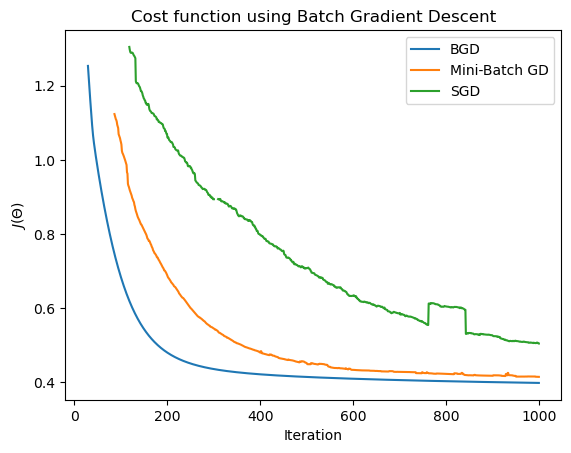

In [16]:
n_iter = 1000

BGD_theta,BGD_cost_history,BGD_theta_history = gradient_descent(X_b,y,theta,alpha=0.02,iterations=n_iter)

mini_batch_theta,mini_batch_cost_history,mini_batch_theta_history = mini_batch_gradient_descent(X_b,y,theta,alpha=0.01,iterations=n_iter, batch_size=30)

SGD_theta,SGD_cost_history,SGD_theta_history = stochastic_gradient_descent(X_b,y,theta,alpha=0.004,iterations=n_iter)

import matplotlib.pyplot as plt
plt.plot(BGD_cost_history)
plt.plot(mini_batch_cost_history)
plt.plot(SGD_cost_history)
plt.xlabel("Iteration")
plt.ylabel("$J(\Theta)$")
#plt.yscale("log")
plt.title("Cost function using Batch Gradient Descent")
plt.legend(["BGD","Mini-Batch GD","SGD"])

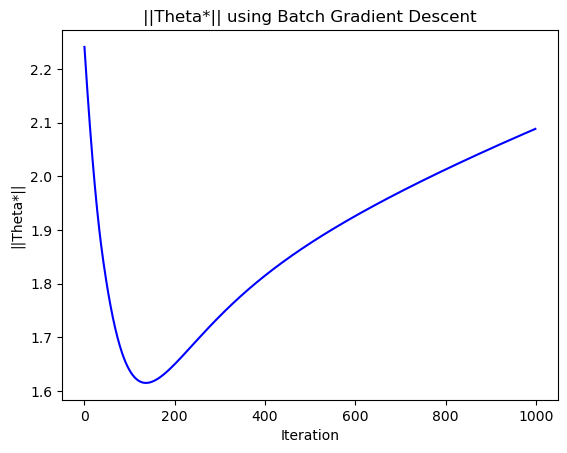

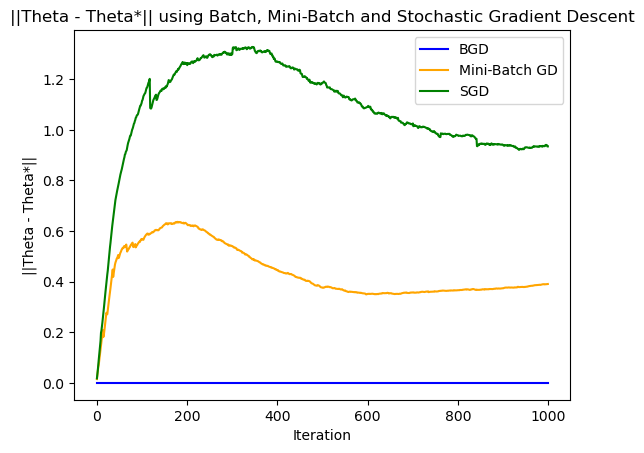

In [19]:
BGD_thetas = np.linalg.norm(BGD_theta_history, axis=1)

BGD_theta_diff = BGD_theta_history - BGD_theta_history
BGD_theta_norm = np.linalg.norm(BGD_theta_diff, axis=1)

mini_batch_theta_diff = mini_batch_theta_history - BGD_theta_history
mini_batch_theta_norm = np.linalg.norm(mini_batch_theta_diff, axis=1)

SGD_theta_diff = SGD_theta_history - BGD_theta_history
SGD_theta_norm = np.linalg.norm(SGD_theta_diff, axis=1)

plt.plot(BGD_thetas, color='blue')
plt.xlabel("Iteration")
plt.ylabel("||Theta*||")
plt.title("||Theta*|| using Batch Gradient Descent")
plt.show()

plt.plot(BGD_theta_norm, color='blue')
plt.plot(mini_batch_theta_norm, color='orange')
plt.plot(SGD_theta_norm, color='green')
plt.xlabel("Iteration")
plt.legend(["BGD","Mini-Batch GD","SGD"])
plt.ylabel("||Theta - Theta*||")
plt.title("||Theta - Theta*|| using Batch, Mini-Batch and Stochastic Gradient Descent")
plt.show()